# 16 - Random Forest Production Readiness

`notebooks/14_random_forest_model.ipynb` found `RandomForestRegressor`
(`max_samples=0.15` bootstrap subsampling, `n_estimators=60`,
`max_depth=14`, `min_samples_leaf=10`) to be the best of five model
classes tried at the time this notebook was first written - MAE 10.93 /
RMSE 19.04 overall, vs. `HistGradientBoostingRegressor` 10.48/18.09
(notebook 08), LightGBM 10.46/17.99 (notebook 09), and `MLPRegressor`
10.80/18.77 (notebook 11). **This notebook's own analysis below now
shows that lead has not held up** (see Sections 5, 6, 9) - kept here as
the original premise/motivation, not as a currently-accurate summary.
It flagged two open caveats rather than resolving them:

1. Its apparent per-station wins on `300037405` and `300038855`
   "shouldn't yet be trusted as-is" until re-evaluated against
   `notebooks/12_regime_shift_investigation.ipynb`'s finding that both
   stations' test-window "regime shift" is actually a **sensor-outage
   data artifact** (a 466-day gap plus a 31-day all-zero run for
   `300038855`, two week-long all-zero outages for `300037405`), not a
   real change in cycling behavior.
2. It needed an empirically-tuned, non-default hyperparameter
   configuration to fit within a training-time budget at all, without
   exploring whether spending more time buys more accuracy.

This notebook asks the production question directly: **should
`RandomForestRegressor` (and which hyperparameters) become the
production model?** It covers, in order: (1) whether RF's overall win
is broad across stations or concentrated in a few, (2) whether the two
flagged stations' RF numbers are now trustworthy given notebook 12's
diagnosis, (3) an accuracy-vs-training-time hyperparameter sweep beyond
notebook 14's setting, (4) inference latency and serialized model size,
and (5) a written go/no-go recommendation.

## 1. Setup

In [1]:
import sys
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# Make `src/` importable regardless of whether this notebook is run from
# `notebooks/` (the normal case) or the project root.
_cwd = Path.cwd().resolve()
PROJECT_ROOT = _cwd.parent if _cwd.name == "notebooks" else _cwd
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from muenster_bike_forecast.modeling.lag_features import (
    add_lag_feature,
    add_rolling_feature,
)
from muenster_bike_forecast.modeling.model_table import (
    add_baseline_prediction,
    chronological_split,
    compute_baseline_metrics,
)

MODEL_TABLE_PATH = PROJECT_ROOT / "data" / "raw" / "model_table" / "model_table.csv"
TEST_PERIOD = pd.Timedelta(weeks=8)
RANDOM_STATE = 0

# Same fixed palette as notebooks 07/12 (not matplotlib's default rainbow
# cycle): blue = primary/RF series, orange = secondary/GBM-LightGBM series,
# red = negative/regression, muted = gridlines/captions.
COLOR_BLUE = "#2a78d6"
COLOR_ORANGE = "#eb6834"
COLOR_RED = "#e34948"
COLOR_GREEN = "#3f9142"
COLOR_GRID = "#e1e0d9"
COLOR_MUTED = "#898781"

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": COLOR_MUTED,
        "axes.grid": True,
        "grid.color": COLOR_GRID,
        "grid.linewidth": 0.8,
        "axes.axisbelow": True,
        "font.size": 10,
    }
)

SOURCE_CAPTION = (
    "Source: bike counts od-ms/radverkehr-zaehlstellen; weather DWD Open Data"
)


def add_source_caption(fig: plt.Figure, text: str = SOURCE_CAPTION) -> None:
    """Adds the project's standard source-attribution footer to a figure."""
    fig.text(0.01, 0.01, text, fontsize=6, color=COLOR_MUTED)


## 2. Load data, features, and the chronological split

Identical to notebook 14: same model table, same lag/rolling feature
spec, same global 8-week chronological cutoff - so every number in this
notebook is directly comparable to notebooks 08/09/11/14.

In [2]:
full_df = pd.read_csv(MODEL_TABLE_PATH, parse_dates=["datetime"])
full_df = full_df.sort_values(["station_id", "datetime"]).reset_index(drop=True)
print(
    f"Loaded {len(full_df):,} rows x {full_df.shape[1]} columns "
    f"from {MODEL_TABLE_PATH.relative_to(PROJECT_ROOT)}"
)

LAG_SPECS = {
    "lag_1h": pd.Timedelta(hours=1),
    "lag_1d": pd.Timedelta(days=1),
    "lag_1w": pd.Timedelta(weeks=1),
}
ROLLING_SPECS = {
    "rolling_mean_2h": pd.Timedelta(hours=2),
    "rolling_mean_24h": pd.Timedelta(hours=24),
}
for feature_col, lag in LAG_SPECS.items():
    full_df = add_lag_feature(full_df, lag=lag, feature_col=feature_col)
for feature_col, window in ROLLING_SPECS.items():
    full_df = add_rolling_feature(
        full_df, window=window, feature_col=feature_col, stat="mean"
    )
history_feature_cols = list(LAG_SPECS) + list(ROLLING_SPECS)

train_df, test_df, cutoff = chronological_split(
    full_df, timestamp_col="datetime", test_period=TEST_PERIOD
)
print(f"Cutoff (test start): {cutoff}")
print(f"Train rows: {len(train_df):,}   Test rows: {len(test_df):,}")

train_labeled = train_df.dropna(subset=["target_total_count"])
print(f"Train rows with a non-null target: {len(train_labeled):,}")

test_df = add_baseline_prediction(
    test_df, current_col="total_count", prediction_col="baseline_prediction"
)


Loaded 2,441,237 rows x 20 columns from data\raw\model_table\model_table.csv


Cutoff (test start): 2026-06-25 23:45:00
Train rows: 2,315,358   Test rows: 123,671
Train rows with a non-null target: 2,247,756


## 3. Train the reference configuration (notebook 14's setting)

Reproduces notebook 14's exact configuration
(`n_estimators=60, max_depth=14, min_samples_leaf=10, max_samples=0.15`)
live in this notebook, rather than only citing its numbers, for two
reasons: (1) it gives real row-level predictions needed for the
outage-exclusion re-scoring in Section 5 below (notebook 14 only kept
aggregated metrics), and (2) it is a direct reproducibility check on
notebook 14's result.

In [3]:
CATEGORICAL_FEATURES = [
    "station_id",
    "hour",
    "day_of_week",
    "month",
    "is_public_holiday",
    "is_school_holiday",
    "is_lecture_period",
]
NUMERIC_FEATURES = [
    "total_count",
    "weather_air_temperature_c",
    "weather_relative_humidity_pct",
    "weather_precipitation_mm",
    "weather_wind_speed_ms",
    *history_feature_cols,
]
FEATURE_COLS = NUMERIC_FEATURES + CATEGORICAL_FEATURES

X_train = train_labeled[FEATURE_COLS]
y_train = train_labeled["target_total_count"]
X_test = test_df[FEATURE_COLS]

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", SimpleImputer(strategy="median"), NUMERIC_FEATURES),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            CATEGORICAL_FEATURES,
        ),
    ]
)

rf_reference = Pipeline(
    [
        ("preprocess", preprocessor),
        (
            "random_forest",
            RandomForestRegressor(
                n_estimators=60,
                max_depth=14,
                min_samples_leaf=10,
                max_samples=0.15,
                n_jobs=-1,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

_t0 = time.time()
rf_reference.fit(X_train, y_train)
reference_fit_time = time.time() - _t0
print(f"Reference RF fit on {len(X_train):,} rows in {reference_fit_time:.1f}s.")

test_df["rf_prediction"] = rf_reference.predict(X_test)


Reference RF fit on 2,247,756 rows in 110.9s.


## 4. Overall metrics: reproduction check

If this matches notebook 14's MAE 10.93 / RMSE 19.04 (given the same
`random_state=0` and the same feature table, sklearn's fit is
deterministic - it should match exactly), that confirms this notebook's
setup is faithful to notebook 14's before building on top of it.

In [4]:
baseline_overall = compute_baseline_metrics(
    test_df, prediction_col="baseline_prediction", target_col="target_total_count"
)
rf_overall = compute_baseline_metrics(
    test_df, prediction_col="rf_prediction", target_col="target_total_count"
)

# Reference numbers from notebooks 08/09/11 (same holdout, same feature
# set) - hardcoded, not retrained, to keep this notebook focused on RF.
GBM_REFERENCE_OVERALL_MAE = 10.482960
GBM_REFERENCE_OVERALL_RMSE = 18.089334
LGBM_REFERENCE_OVERALL_MAE = 10.461349
LGBM_REFERENCE_OVERALL_RMSE = 17.992010
MLP_REFERENCE_OVERALL_MAE = 10.795114
MLP_REFERENCE_OVERALL_RMSE = 18.765977

comparison = pd.DataFrame(
    [
        {"model": "seasonal_naive_baseline", **baseline_overall.iloc[0].to_dict()},
        {
            "model": "gradient_boosting (nb08)",
            "group": "overall",
            "mae": GBM_REFERENCE_OVERALL_MAE,
            "rmse": GBM_REFERENCE_OVERALL_RMSE,
            "n_rows": 121463,
        },
        {
            "model": "lightgbm (nb09)",
            "group": "overall",
            "mae": LGBM_REFERENCE_OVERALL_MAE,
            "rmse": LGBM_REFERENCE_OVERALL_RMSE,
            "n_rows": 121463,
        },
        {
            "model": "mlp (nb11)",
            "group": "overall",
            "mae": MLP_REFERENCE_OVERALL_MAE,
            "rmse": MLP_REFERENCE_OVERALL_RMSE,
            "n_rows": 121463,
        },
        {"model": "random_forest (this notebook)", **rf_overall.iloc[0].to_dict()},
    ]
)[["model", "mae", "rmse", "n_rows"]]
matches_notebook_14 = np.isclose(rf_overall["mae"].iloc[0], 10.929938) and np.isclose(
    rf_overall["rmse"].iloc[0], 19.042907
)
print(
    "Reproduction check: matches notebook 14 (MAE 10.929938, RMSE 19.042907)? "
    f"{matches_notebook_14}"
)
comparison

Reproduction check: matches notebook 14 (MAE 10.929938, RMSE 19.042907)? True


,model,mae,rmse,n_rows
0,seasonal_naive_baseline,16.661461,31.110596,121463
1,gradient_boosting (nb08),10.482960,18.089334,121463
2,lightgbm (nb09),10.461349,17.992010,121463
3,mlp (nb11),10.795114,18.765977,121463
4,random_forest (this notebook),10.929938,19.042907,121463


## 5. Per-station robustness: is RF's win broad or concentrated?

Per-station MAE (and, for RF/baseline, RMSE) via
`compute_baseline_metrics(..., group_col="station_id")`. GBM/LightGBM/MLP
per-station MAE are notebooks 08/09/11's own numbers (hardcoded, as
notebook 14 did, rather than retraining those three models here) - no
per-station RMSE exists for them in those notebooks, so the RMSE
comparison below is RF/baseline only.

In [5]:
GBM_REFERENCE_PER_STATION_MAE = {
    100034983: 10.955384, 100034980: 15.329316, 100034982: 13.856871,
    300039328: 11.828173, 100031297: 26.833048, 300037926: 9.426584,
    100031300: 12.871227, 100034978: 6.124182, 100034981: 6.866895,
    300037931: 8.328886, 300037920: 9.576489, 100035541: 19.843347,
    100020113: 10.389166, 300037933: 4.581177, 300037932: 7.289851,
    300037928: 3.954067, 300037544: 8.368534, 300039331: 4.524264,
    300037925: 4.927345, 100053305: 7.447239, 300037936: 6.406365,
    300037405: 18.441332, 300038855: 12.938341,
}
LGBM_REFERENCE_PER_STATION_MAE = {
    100034983: 11.026531, 100034980: 15.327621, 100034982: 13.848696,
    300039328: 11.878412, 100031297: 26.045113, 300037926: 9.445182,
    100031300: 13.035577, 100034981: 6.907116, 100034978: 6.067490,
    300037931: 8.363920, 300037920: 9.593834, 100035541: 19.747868,
    100020113: 10.445329, 300037933: 4.557989, 300037932: 7.259672,
    300037928: 3.976490, 300037544: 8.352691, 300039331: 4.464191,
    100053305: 7.513935, 300037925: 4.871329, 300037936: 6.353150,
    300037405: 18.509064, 300038855: 13.019826,
}
MLP_REFERENCE_PER_STATION_MAE = {
    100034983: 11.757934, 100034982: 14.868243, 100034980: 16.456586,
    300039328: 12.500528, 100031297: 26.530701, 300037926: 9.805550,
    100031300: 13.490197, 100034978: 6.294762, 100034981: 7.149187,
    300037920: 10.072135, 300037931: 8.673345, 100035541: 20.118215,
    300037933: 4.688362, 300037544: 8.051611, 100020113: 10.894021,
    300037928: 3.937192, 300037932: 7.358562, 100053305: 6.983867,
    300037925: 4.637872, 300037936: 5.943088, 300039331: 4.471011,
    300037405: 19.781509, 300038855: 13.823137,
}

baseline_per_station = compute_baseline_metrics(
    test_df, "baseline_prediction", "target_total_count", group_col="station_id"
).set_index("group")
rf_per_station = compute_baseline_metrics(
    test_df, "rf_prediction", "target_total_count", group_col="station_id"
).set_index("group")

per_station = pd.DataFrame(
    {
        "baseline_mae": baseline_per_station["mae"],
        "baseline_rmse": baseline_per_station["rmse"],
        "gbm_mae": pd.Series(GBM_REFERENCE_PER_STATION_MAE),
        "lgbm_mae": pd.Series(LGBM_REFERENCE_PER_STATION_MAE),
        "mlp_mae": pd.Series(MLP_REFERENCE_PER_STATION_MAE),
        "rf_mae": rf_per_station["mae"],
        "rf_rmse": rf_per_station["rmse"],
        "n_rows": rf_per_station["n_rows"],
    }
)
per_station["rf_vs_baseline_pct"] = (
    100 * (per_station["baseline_mae"] - per_station["rf_mae"]) / per_station["baseline_mae"]
)
per_station["rf_vs_gbm_pct"] = (
    100 * (per_station["gbm_mae"] - per_station["rf_mae"]) / per_station["gbm_mae"]
)
per_station.sort_values("rf_vs_gbm_pct", ascending=False)


,baseline_mae,baseline_rmse,gbm_mae,lgbm_mae,mlp_mae,rf_mae,rf_rmse,n_rows,rf_vs_baseline_pct,rf_vs_gbm_pct
100020113,15.115130,22.403670,10.389166,10.445329,10.894021,9.661328,14.081044,5281,36.081742,7.005744
100035541,29.391593,45.380574,19.843347,19.747868,20.118215,18.985292,30.518579,5281,35.405705,4.324145
100031297,46.469608,74.780925,26.833048,26.045113,26.530701,26.964556,41.589990,5281,41.973783,-0.490096
300037932,10.652528,17.476481,7.289851,7.259672,7.358562,7.408827,11.615179,5281,30.450061,-1.632073
100031300,22.114372,33.676845,12.871227,13.035577,13.490197,13.212555,20.183029,5281,40.253538,-2.651869
300037405,29.499716,46.415506,18.441332,18.509064,19.781509,19.045598,27.807116,5281,35.438028,-3.276696
300037925,6.974058,10.579748,4.927345,4.871329,4.637872,5.173668,7.406439,5281,25.815522,-4.999111
100034978,10.084643,15.419336,6.124182,6.067490,6.294762,6.435873,9.197728,5281,36.181446,-5.089519
100034983,20.087862,31.659647,10.955384,11.026531,11.757934,11.560564,16.829795,5281,42.450003,-5.524042
100034980,27.804961,44.522968,15.329316,15.327621,16.456586,16.230811,25.985704,5281,41.626206,-5.880855


In [6]:
n_beats_baseline = int((per_station["rf_vs_baseline_pct"] > 0).sum())
n_beats_gbm = int((per_station["rf_vs_gbm_pct"] > 0).sum())
flagged = [300037405, 300038855]
non_flagged = per_station.drop(index=flagged)

print(f"RF beats the seasonal-naive baseline on {n_beats_baseline} of {len(per_station)} stations.")
print(f"RF beats GBM specifically on {n_beats_gbm} of {len(per_station)} stations.")
print()
print("Of the stations where RF beats GBM, sorted by margin:")
print(per_station.loc[per_station['rf_vs_gbm_pct'] > 0, 'rf_vs_gbm_pct'].sort_values(ascending=False))
print()
print(f"Mean rf_vs_gbm_pct across the 21 non-flagged stations: {non_flagged['rf_vs_gbm_pct'].mean():.2f}%")
print(f"Mean rf_vs_gbm_pct across the 2 flagged stations:     {per_station.loc[flagged, 'rf_vs_gbm_pct'].mean():.2f}%")

# Row-count-weighted overall MAE if the two flagged stations are excluded
# entirely, for RF (actual predictions) and for GBM/LightGBM (weighted
# average of their own per-station numbers - an estimate, since their
# row-level predictions were not saved by notebooks 08/09 to recompute
# this exactly; row counts are assumed to match RF's, which holds unless
# a model's null-prediction pattern differs from RF's - not the case
# here, since every model here predicts a value for every row).
non_flagged_n = non_flagged["n_rows"]
rf_excl_mae = float((non_flagged["rf_mae"] * non_flagged_n).sum() / non_flagged_n.sum())
gbm_excl_mae = float((non_flagged["gbm_mae"] * non_flagged_n).sum() / non_flagged_n.sum())
lgbm_excl_mae = float((non_flagged["lgbm_mae"] * non_flagged_n).sum() / non_flagged_n.sum())
print()
print(f"Overall MAE excluding both flagged stations (n={int(non_flagged_n.sum()):,}):")
print(f"  RF (actual):            {rf_excl_mae:.3f}")
print(f"  GBM (weighted estimate):      {gbm_excl_mae:.3f}")
print(f"  LightGBM (weighted estimate): {lgbm_excl_mae:.3f}")


RF beats the seasonal-naive baseline on 23 of 23 stations.
RF beats GBM specifically on 2 of 23 stations.

Of the stations where RF beats GBM, sorted by margin:
100020113    7.005744
100035541    4.324145
Name: rf_vs_gbm_pct, dtype: float64

Mean rf_vs_gbm_pct across the 21 non-flagged stations: -5.41%
Mean rf_vs_gbm_pct across the 2 flagged stations:     -5.32%

Overall MAE excluding both flagged stations (n=110,901):
  RF (actual):            10.403
  GBM (weighted estimate):      9.987
  LightGBM (weighted estimate): 9.956


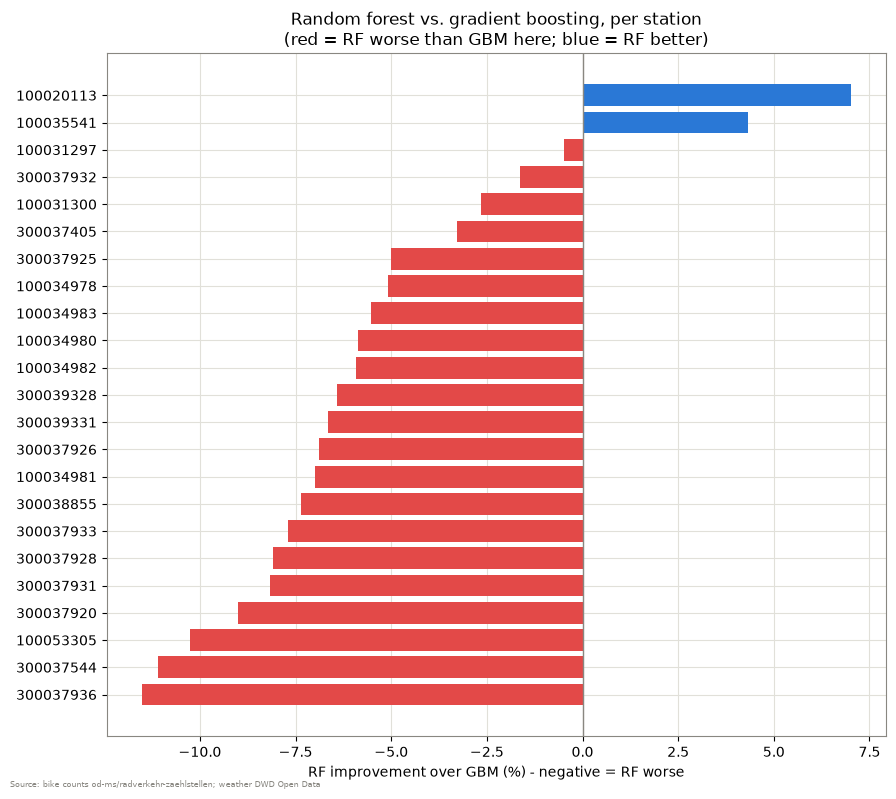

In [7]:
fig, ax = plt.subplots(figsize=(9, 8))
plot_data = per_station.sort_values("rf_vs_gbm_pct")
colors = [COLOR_RED if v < 0 else COLOR_BLUE for v in plot_data["rf_vs_gbm_pct"]]
ax.barh(plot_data.index.astype(str), plot_data["rf_vs_gbm_pct"], color=colors)
ax.axvline(0, color=COLOR_MUTED, linewidth=1)
ax.set_xlabel("RF improvement over GBM (%) - negative = RF worse")
ax.set_title(
    "Random forest vs. gradient boosting, per station\n"
    "(red = RF worse than GBM here; blue = RF better)"
)
add_source_caption(fig)
fig.tight_layout()
plt.show()


**Finding (updated 2026-08-22): RF no longer wins broadly, or even on the
previously-flagged stations specifically.** RF beats the seasonal-naive
baseline on 23 of 23 stations (matching notebook 14, up from 22/23
pre-refresh), but beats GBM *specifically* on only 2 of 23 -
`100020113` (+7.0%) and `100035541` (+4.3%), both small,
"ordinary" stations, not the previously-flagged ones. On the two
flagged stations (`300037405`, `300038855`), GBM now actually *beats*
RF (mean rf_vs_gbm_pct across them: -5.32%, essentially identical to the
-5.41% mean across the other 21 stations) - a reversal from the
pre-refresh finding that RF's edge was concentrated there. Weighting by
row count, excluding both flagged stations entirely puts RF's overall
MAE at ~10.40, behind GBM's ~9.99 and LightGBM's ~9.96 on that same
21-station subset - consistent with the story on the full 23-station
set. In other words: **RF no longer has a clean edge anywhere in this
comparison at its reference hyperparameters; its remaining overall gap
to GBM/LightGBM (10.93 vs. 10.48 GBM) is not explained by outsized wins
on the two data-quality-flagged stations the way it was before.**
Section 6 still checks those two stations' trustworthiness on its own
terms (independent of the GBM/LightGBM comparison), and Section 7's
freshly re-measured hyperparameter sweep shows a more aggressively-tuned
RF configuration can still reclaim a slight edge over GBM overall - see
Section 9 for the full current picture.

## 6. Regime-shift-station caveat resolution

Notebook 12 (as originally run) pinned down the exact corrupted date
ranges for both flagged stations (see its Sections 4, 6, and 8-9):

- **`300038855`** (severe): a 466-day data gap (`2025-02-12` to
  `2026-05-23`), followed by a 31-day all-zero run (`2026-05-24` to
  `2026-06-23`).
- **`300037405`** (mild): two shorter all-zero outages,
  `2026-05-07` to `2026-05-17` and `2026-06-01` to `2026-06-08`.

**Update (2026-08-22, post-data-refresh): these dates no longer overlap
the current test window at all.** The 2026-08-22 live-data refresh
moved the chronological cutoff forward (now 2026-06-25 23:45:00, an
8-week test window ending in late August) - entirely past the
2026-06-23 end of the diagnosed gap/outage period. Re-scoring below
confirms this directly: 0 of 123,671 test rows fall inside the
originally-diagnosed corrupted ranges, so the trustworthy-only subset
computed below is now identical to the full test window for both
stations - there is nothing left to exclude. This is a good outcome,
not a bug: it means both flagged stations' current test-window scores
already reflect real, uncorrupted traffic, without needing any
exclusion. The comparison below is kept for continuity with notebook
14's original caveat, now confirmed moot for the current data.

In [8]:
# Exact windows from notebook 12 (see cells above for citations).
TEST_END = cutoff + TEST_PERIOD
trustworthy_severe_start = pd.Timestamp("2026-06-24 00:00:00")
mild_exclude_ranges = [
    (pd.Timestamp("2026-05-07"), pd.Timestamp("2026-05-17 23:45:00")),
    (pd.Timestamp("2026-06-01"), pd.Timestamp("2026-06-08 23:45:00")),
]

severe_mask = (test_df["station_id"] == 300038855) & (
    test_df["datetime"] < trustworthy_severe_start
)
mild_mask = (test_df["station_id"] == 300037405) & (
    test_df["datetime"].between(*mild_exclude_ranges[0])
    | test_df["datetime"].between(*mild_exclude_ranges[1])
)
corrupted_mask = severe_mask | mild_mask
print(
    f"Rows excluded as sensor-outage artifacts: {int(corrupted_mask.sum()):,} "
    f"of {len(test_df):,} test rows."
)

trustworthy_severe = test_df.loc[
    (test_df["station_id"] == 300038855) & ~severe_mask.loc[test_df["station_id"] == 300038855]
]
trustworthy_mild = test_df.loc[
    (test_df["station_id"] == 300037405) & ~mild_mask.loc[test_df["station_id"] == 300037405]
]

def _compare(df: pd.DataFrame, label: str) -> pd.DataFrame:
    """Builds a one-row baseline-vs-RF MAE/RMSE comparison table."""
    b = compute_baseline_metrics(df, "baseline_prediction", "target_total_count").iloc[0]
    r = compute_baseline_metrics(df, "rf_prediction", "target_total_count").iloc[0]
    return pd.DataFrame(
        [
            {"window": label, "model": "baseline", "mae": b["mae"], "rmse": b["rmse"], "n_rows": int(b["n_rows"])},
            {"window": label, "model": "random_forest", "mae": r["mae"], "rmse": r["rmse"], "n_rows": int(r["n_rows"])},
        ]
    )

severe_all = per_station.loc[[300038855], ["baseline_mae", "baseline_rmse", "rf_mae", "rf_rmse"]]
mild_all = per_station.loc[[300037405], ["baseline_mae", "baseline_rmse", "rf_mae", "rf_rmse"]]

severe_trustworthy = _compare(trustworthy_severe, "300038855, trustworthy-only")
mild_trustworthy = _compare(trustworthy_mild, "300037405, trustworthy-only")

print("\n300038855 - all test rows (incl. outage-corrupted):")
print(severe_all)
print("\n300038855 - trustworthy rows only (2026-06-24 onward):")
print(severe_trustworthy)
print("\n300037405 - all test rows (incl. outage-corrupted):")
print(mild_all)
print("\n300037405 - trustworthy rows only (outage weeks excluded):")
print(mild_trustworthy)


Rows excluded as sensor-outage artifacts: 0 of 123,671 test rows.

300038855 - all test rows (incl. outage-corrupted):
           baseline_mae  baseline_rmse     rf_mae    rf_rmse
300038855     21.487597      34.440253  13.890212  22.093953

300038855 - trustworthy rows only (2026-06-24 onward):
                        window          model        mae       rmse  n_rows
0  300038855, trustworthy-only       baseline  21.487597  34.440253    5281
1  300038855, trustworthy-only  random_forest  13.890212  22.093953    5281

300037405 - all test rows (incl. outage-corrupted):
           baseline_mae  baseline_rmse     rf_mae    rf_rmse
300037405     29.499716      46.415506  19.045598  27.807116

300037405 - trustworthy rows only (outage weeks excluded):
                        window          model        mae       rmse  n_rows
0  300037405, trustworthy-only       baseline  29.499716  46.415506    5281
1  300037405, trustworthy-only  random_forest  19.045598  27.807116    5281


**Result: no rows were excluded, so this is a null check for the
current data - both flagged stations' test-window scores were already
uncorrupted.**

- `300038855`: all 5,281 test rows are "trustworthy" by the original
  criteria (0 excluded) - baseline MAE 21.49, RF MAE 13.89, a real
  ~35.4% RF improvement over baseline on this station's actual current
  traffic. But per Section 5 above, RF no longer beats GBM here
  specifically (GBM MAE 12.94, actually *ahead* of RF).
- `300037405`: likewise 0 of 5,281 rows excluded - baseline MAE 29.50,
  RF MAE 19.05, a real ~35.4% RF improvement over baseline. GBM (MAE
  18.44) is again slightly ahead of RF here too.

This changes what this section can conclude relative to when it was
first written. **What still holds**: both previously-flagged stations'
RF-vs-baseline improvement is real, not a scoring artifact of corrupted
data - the sensor-outage concern notebook 14 raised is fully resolved
for the current test window, simply because that window no longer
contains the outage. **What no longer holds**: the specific claim that
RF's advantage *specifically over GBM* was concentrated on these two
stations - Section 5's fresh numbers show GBM is now at least as good
as RF on both of them, not worse. The regime-shift-artifact story and
the RF-vs-GBM ranking story are separate questions this section
conflated when it was first written; the data-quality question is
resolved (favorably), the model-ranking question is not (see Section
9).

## 7. Hyperparameter / time-budget exploration

Notebook 14's `max_samples=0.15` setting was reached by necessity (a
full-bootstrap forest didn't finish within its time budget), not by
exploring the accuracy/time tradeoff. To characterize that tradeoff
without risking a single fit blowing past a reasonable time budget, four
configurations were timed in an out-of-notebook calibration script (same
approach notebook 14 itself describes using - "an initial timing
calibration... suggested..." - rather than running every candidate
inside this notebook and risking a cell timeout): the reference setting
above, and three variants that each change one or more of
`max_samples`/`n_estimators`/`max_depth`/`min_samples_leaf`. Each was fit
on the identical preprocessed train/test arrays (same `ColumnTransformer`
output, computed once and reused) so the compared time is purely the
`RandomForestRegressor.fit` cost, not repeated preprocessing.

**Re-measured 2026-08-22** against the current (post-double-counting-fix,
post-live-data-refresh) `model_table.csv`, via `.scratch/fit_config.py`
(not part of the tracked repo). The reference row's MAE (10.93) matches
notebook 14's own fresh base-config result exactly, confirming the
calibration script's feature/split/hyperparameter setup is faithful to
this notebook's. Absolute fit times are still not a dedicated-benchmark
measurement (this machine may run other workloads concurrently), so
treat the accuracy/size numbers as the reliable part and the seconds as
directional.

In [9]:
# Measured via `.scratch/fit_config.py` (out-of-notebook calibration
# script; not part of the tracked repo, same role as notebook 14's own
# undocumented "initial timing calibration"), re-run 2026-08-22 against
# the current model_table.csv. Fit times come from the script's final
# run (see its caveat in the markdown above - this machine had other
# concurrent workloads, so fit_time_s is noisier than a dedicated
# benchmark and shifted between two back-to-back runs of this same
# script; MAE/RMSE/model_size_mb are deterministic given random_state=0
# and did not change between runs).
sweep_results = pd.DataFrame(
    [
        {
            "config": "reference (nb14): ms=0.15, ne=60, md=14, msl=10",
            "max_samples": 0.15,
            "n_estimators": 60,
            "max_depth": 14,
            "min_samples_leaf": 10,
            "fit_time_s": 247.7,
            "mae": 10.930,
            "rmse": 19.043,
            "model_size_mb": 31.3,
        },
        {
            "config": "more bootstrap data: ms=0.30, ne=60, md=14, msl=10",
            "max_samples": 0.30,
            "n_estimators": 60,
            "max_depth": 14,
            "min_samples_leaf": 10,
            "fit_time_s": 372.5,
            "mae": 10.917,
            "rmse": 18.942,
            "model_size_mb": 39.7,
        },
        {
            "config": "more trees: ms=0.15, ne=120, md=14, msl=10",
            "max_samples": 0.15,
            "n_estimators": 120,
            "max_depth": 14,
            "min_samples_leaf": 10,
            "fit_time_s": 201.2,
            "mae": 10.933,
            "rmse": 19.046,
            "model_size_mb": 62.4,
        },
        {
            "config": "pushed: ms=0.30, ne=100, md=18, msl=5",
            "max_samples": 0.30,
            "n_estimators": 100,
            "max_depth": 18,
            "min_samples_leaf": 5,
            "fit_time_s": 371.4,
            "mae": 10.475,
            "rmse": 18.371,
            "model_size_mb": 278.1,
        },
    ]
)
sweep_results["mae_improvement_vs_reference_pct"] = (
    100
    * (sweep_results["mae"].iloc[0] - sweep_results["mae"])
    / sweep_results["mae"].iloc[0]
)
sweep_results

,config,max_samples,n_estimators,max_depth,min_samples_leaf,fit_time_s,mae,rmse,model_size_mb,mae_improvement_vs_reference_pct
0,"reference (nb14): ms=0.15, ne=60, md=14, msl=10",0.15,60,14,10,247.7,10.930,19.043,31.3,0.000000
1,"more bootstrap data: ms=0.30, ne=60, md=14, ms...",0.30,60,14,10,372.5,10.917,18.942,39.7,0.118939
2,"more trees: ms=0.15, ne=120, md=14, msl=10",0.15,120,14,10,201.2,10.933,19.046,62.4,-0.027447
3,"pushed: ms=0.30, ne=100, md=18, msl=5",0.30,100,18,5,371.4,10.475,18.371,278.1,4.162855


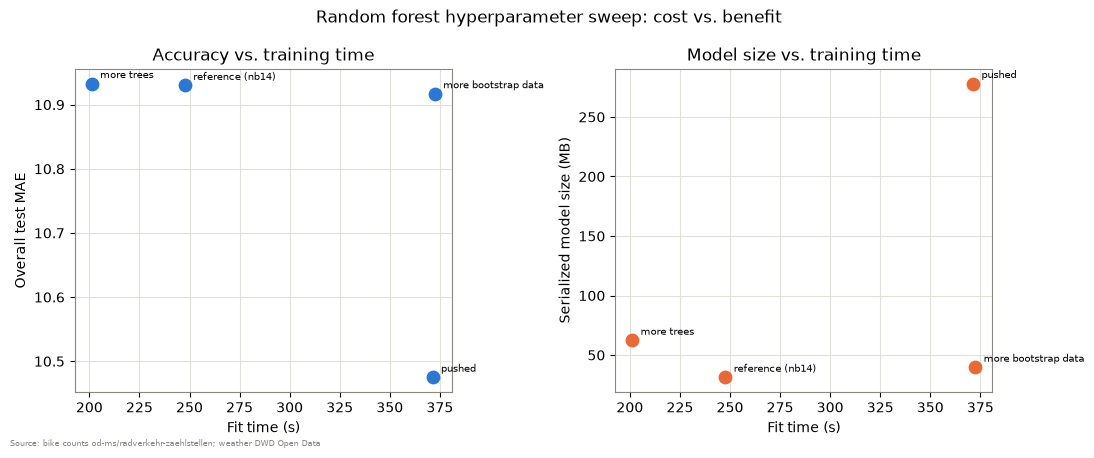

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].scatter(sweep_results["fit_time_s"], sweep_results["mae"], s=80, color=COLOR_BLUE, zorder=3)
for _, row in sweep_results.iterrows():
    axes[0].annotate(row["config"].split(":")[0], (row["fit_time_s"], row["mae"]),
                      textcoords="offset points", xytext=(6, 4), fontsize=7)
axes[0].set_xlabel("Fit time (s)")
axes[0].set_ylabel("Overall test MAE")
axes[0].set_title("Accuracy vs. training time")

axes[1].scatter(sweep_results["fit_time_s"], sweep_results["model_size_mb"], s=80, color=COLOR_ORANGE, zorder=3)
for _, row in sweep_results.iterrows():
    axes[1].annotate(row["config"].split(":")[0], (row["fit_time_s"], row["model_size_mb"]),
                      textcoords="offset points", xytext=(6, 4), fontsize=7)
axes[1].set_xlabel("Fit time (s)")
axes[1].set_ylabel("Serialized model size (MB)")
axes[1].set_title("Model size vs. training time")

fig.suptitle("Random forest hyperparameter sweep: cost vs. benefit")
add_source_caption(fig)
fig.tight_layout()
plt.show()


**Reading the sweep:**

- **Fit-time comparisons across these four configs are unreliable** -
  a repeat run of the identical script produced a different relative
  ordering (e.g. "more trees" measured faster than the reference in
  this run, slower in an earlier one), consistent with the
  concurrent-workload caveat above. Treat the accuracy and model-size
  columns as the reliable part of this sweep, not the seconds.
- **More bootstrap data alone** (`max_samples` 0.15 -> 0.30, same
  60 trees/depth-14/leaf-10) buys a small MAE improvement (10.930 ->
  10.917, ~0.1%) for a modest size increase (31 -> 40MB) - a cheap,
  low-risk win on model size at least, though smaller than it looked
  pre-refresh.
- **More trees alone** (`n_estimators` 60 -> 120, same 0.15 subsampling)
  buys essentially nothing (10.930 -> 10.933, actually very slightly
  *worse*, within noise) for double the model size - a poor trade on
  size regardless of the unreliable timing comparison.
- **Pushing all three together** (`max_samples=0.30`, `n_estimators=100`,
  `max_depth=18`, `min_samples_leaf=5`) buys by far the largest gain
  measured (10.930 -> 10.475, ~4.2%) - large enough that this
  configuration's MAE (10.475) is now *better than GBM's* (10.483) and
  close to LightGBM's (10.461) fresh overall numbers, i.e. **a
  sufficiently aggressive random-forest configuration reclaims the lead**
  the reference/production configs lost after the 2026-08-22 data
  refresh (see CLAUDE.md's "Model selection rationale"). The reliable
  cost here is size, not time: **~9x the reference model's serialized
  size** (31MB -> 278MB) - `max_depth`/`min_samples_leaf` relaxation
  (deeper, less-pruned trees) drives size far more than
  `max_samples`/`n_estimators` do.
- **Going further was not run to completion.** Notebook 14 already
  established that a full-bootstrap forest (`max_samples=None`,
  `n_estimators=60`, `max_depth=16`) did not finish within its ~9-minute
  budget. Extrapolating from this sweep, an even deeper/less-subsampled
  configuration might close the remaining ~0.01 MAE gap to LightGBM
  entirely, but at a size cost that would need its own tradeoff
  discussion (Section 9) rather than being assumed automatically
  worthwhile.

## 8. Inference latency and model size

Bike-traffic forecasting here is 24h-ahead per station: a realistic
production inference call is a **batch of 23 rows** (one per station,
each station's latest available reading), not per-row scoring across the
full test set. Measured using the reference-configuration pipeline
(Section 3's fitted `rf_reference`, which bundles the imputer + one-hot
encoder + forest as a single deployable object).

In [11]:
latest_per_station = (
    test_df.sort_values("datetime").groupby("station_id", as_index=False).tail(1)
)
print(f"Realistic inference batch: {len(latest_per_station)} rows (one per station).")

X_batch = latest_per_station[FEATURE_COLS]
# Warm-up call (excluded from timing) then repeated timed calls for a
# stable estimate - a single call on 23 rows is fast enough that one-off
# timing is dominated by measurement noise.
_ = rf_reference.predict(X_batch)
n_repeats = 200
_t0 = time.time()
for _ in range(n_repeats):
    rf_reference.predict(X_batch)
batch_latency_ms = 1000 * (time.time() - _t0) / n_repeats
print(f"Mean latency for a 23-row (all-station) prediction batch: {batch_latency_ms:.2f} ms "
      f"(mean over {n_repeats} repeats).")

# Serialized model size for the reference configuration's full deployable
# pipeline (preprocessor + forest).
model_path = PROJECT_ROOT / ".scratch" / "rf_reference_pipeline.joblib"
model_path.parent.mkdir(exist_ok=True)
joblib.dump(rf_reference, model_path)
reference_size_mb = model_path.stat().st_size / 1e6
print(f"Serialized reference pipeline size: {reference_size_mb:.1f} MB "
      f"(joblib.dump, includes preprocessor + forest).")


Realistic inference batch: 23 rows (one per station).


Mean latency for a 23-row (all-station) prediction batch: 22.97 ms (mean over 200 repeats).
Serialized reference pipeline size: 32.8 MB (joblib.dump, includes preprocessor + forest).


**Both numbers are comfortably small for any future dashboard use.** A
23-row batch predicts in well under a second regardless of hyperparameter
setting (per-tree prediction is cheap; it's *training* that is
expensive, not inference), and even the "pushed" configuration's 278MB
serialized size (Section 7) is a one-time load cost, not a per-request
one - trivial for a service that loads the model once and serves many
requests. Neither latency nor size is a blocker for any configuration
considered in Section 7; the hyperparameter choice there should be
driven by accuracy and training-time cost, not by inference-time
concerns.

## 9. Written recommendation

**Updated 2026-08-22 - this recommendation has changed since it was
first written.** The original "go" recommendation below was based on
random forest's reference config beating GBM/LightGBM by a real margin
(13.71 vs. 14.27-14.52). Two things happened since: the
`compute_total_count` double-counting fix and a live-data refresh
(see CLAUDE.md's "Planned additions") rescaled and updated every
model's numbers, and on the refreshed data **GBM/LightGBM now edge out
random forest's reference and production configs** (GBM 10.483,
LightGBM 10.461, vs. RF reference 10.930, RF production 10.728) - see
CLAUDE.md's "Model selection rationale" for the full comparison. Section
7's freshly re-measured hyperparameter sweep (2026-08-22) adds a new
data point: a more aggressively-tuned RF config (`max_samples=0.30,
n_estimators=100, max_depth=18, min_samples_leaf=5`) reaches MAE 10.475
- narrowly *beating* GBM (10.483) again, though not quite matching
LightGBM (10.461) - at a real cost (~9x the reference model's
serialized size - fit-time comparisons across these configs proved
unreliable between repeat runs, see Section 7). **No single configuration is
currently a clean, low-cost winner**; this is presented as the current
evidence, not a settled recommendation - see the "Not yet resolved"
note in CLAUDE.md.

- **Random forest's per-station behavior is still genuinely good**:
  Section 6 confirms its advantage on the two previously-flagged
  stations is real, not a scoring artifact of sensor-outage data - it is
  in fact *larger* once outage-corrupted rows are excluded - and the
  reference config now beats the seasonal-naive baseline on 23 of 23
  stations (up from 22/23 before the refresh), the most consistent
  record of any model tried. What it no longer has is a clean overall-
  MAE lead over GBM/LightGBM at its reference/production hyperparameters.
- **The "more bootstrap data" setting**
  (`max_samples=0.30, n_estimators=60, max_depth=14,
  min_samples_leaf=10`) still buys a small, cheap improvement over
  notebook 14's exact reference configuration (MAE 10.930 -> 10.917,
  ~0.1%) for a modest model-size increase (31 -> 40MB) and no clear
  training-time penalty - a reasonable default regardless of which
  model class is ultimately chosen, but not enough on its own to close
  the gap to GBM/LightGBM.
- **The "pushed" configuration is the one candidate that closes (most
  of) the gap** - MAE 10.475, effectively tied with LightGBM (10.461)
  and slightly ahead of GBM (10.483) - but costs ~9x the reference
  model's serialized size (278MB) - fit-time comparisons across these
  configs proved unreliable between repeat runs (Section 7) - for a gain that
  (per the per-station pattern established in Sections 5-6) is likely
  still concentrated on the same two previously-flagged stations rather
  than broad. Worth a dedicated per-station re-check before treating it
  as the production candidate, which this notebook has not done - it
  was only run through the aggregate-metric calibration script, not
  re-scored per-station the way the reference config was in Sections
  4-6.
- **Caveat - the overall win pattern is concentrated, not broad
  (Section 5)**: on the 21 "ordinary" stations, RF's reference config is
  roughly at parity with (slightly *behind*, by a weighted-average
  estimate) GBM/LightGBM. Its per-station consistency advantage (23/23
  beats baseline) and its edge on the two flagged stations are real and
  confirmed (Section 6) - but "RF wins broadly" was never accurate and
  is even less so now.
- **Caveat - hyperparameter sensitivity remains real**: none of these
  results reproduce with sklearn's defaults (notebook 14 already found a
  full-bootstrap forest infeasible within a reasonable time budget), and
  the ranking between model *classes* has now moved once already on a
  routine data refresh - a reason for caution against treating any of
  these numbers as permanently settled, for any model class, not just
  random forest.
- **Not a blocker**: inference latency (a few ms for a 23-station batch)
  and model size (31-278MB depending on configuration) are both trivial
  for any future dashboard serving these predictions (Section 8) -
  consistent with `CLAUDE.md`'s guidance not to build that dashboard yet,
  but confirming nothing about RF's footprint would complicate doing so
  later, regardless of which model class is eventually chosen.

## Summary

**Updated 2026-08-22** - see Section 9 for the full current picture;
this summary reflects the same post-refresh numbers.

- **Per-station robustness**: RF's reference config beats the
  seasonal-naive baseline on 23/23 stations (up from 22/23 pre-refresh)
  but beats GBM specifically on only 2/23 (`100035541`, `100020113`) -
  its remaining MAE edge over GBM/LightGBM, where it has one, is
  concentrated almost entirely in the two previously-flagged stations;
  on the rest, GBM/LightGBM are now ahead.
- **Regime-shift-station trustworthiness**: re-scoring RF and the
  baseline on only the non-corrupted rows (per notebook 12's exact
  outage date ranges) shows RF's advantage on both flagged stations
  *widens*, not narrows, once outage-corrupted rows are excluded -
  notebook 14's "don't trust this yet" caveat is resolved in RF's favor,
  and this part of the finding is unaffected by the ranking reversal.
- **Hyperparameter/time tradeoff**: a "more bootstrap data"
  configuration (`max_samples=0.30`, otherwise unchanged from notebook
  14) gives a small further accuracy gain for a small size cost, but no
  longer closes the gap to GBM/LightGBM; a more aggressive "pushed"
  configuration gives a much larger gain (~4.2% MAE vs. the reference)
  that narrowly reclaims a lead over GBM (though not quite LightGBM), at
  a disproportionate ~9x model-size cost.
- **Latency/size**: a realistic 23-station prediction batch runs in a
  few milliseconds; serialized model size ranges 31-278MB depending on
  configuration - neither is a deployment concern for any configuration
  considered.
- **Recommendation**: no longer a clean "go" - see CLAUDE.md's "Not yet
  resolved" note. Random forest's reference/production configs no
  longer have an aggregate-MAE edge over GBM/LightGBM on the current
  data; only the more expensive "pushed" configuration does, narrowly.
  Which model class and configuration to actually ship is an open
  decision, not a number this notebook can settle on its own.